# Project: Cardinal Store - Forecasting Retail Demand
## Orientation and Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_pinball_loss, mean_absolute_error)

import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor

from prophet import Prophet

In [2]:
# pip install prophet

In [3]:
df_fact_sales = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\fact_sales.csv')
df_fact_inventory = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\fact_inventory.csv')
df_fact_replenishment = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\fact_replenishment.csv')
df_dim_store = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\dim_store.csv')
df_dim_product = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\dim_product.csv')
df_dim_promotion = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\dim_promotion.csv')
df_dim_calendar = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\dim_calendar.csv')
df_dim_external_factors = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\dim_external_factors.csv')


In [4]:
import json

with open(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\validation_report.json', 'r') as f:
    vld_rpt = json.load(f)

print(type(vld_rpt))

<class 'dict'>


In [5]:
print(vld_rpt.keys())

dict_keys(['passed', 'failed', 'warnings', 'score', 'dataset_ready', 'row_counts'])


In [6]:
import pprint
pprint.pprint(vld_rpt)

{'dataset_ready': True,
 'failed': [],
 'passed': ['dim_product: no duplicate rows',
            'dim_product: missing values acceptable',
            'dim_store: no duplicate rows',
            'dim_store: missing values acceptable',
            'fact_sales: no duplicate rows',
            'fact_sales: missing values acceptable',
            'fact_inventory: no duplicate rows',
            'fact_inventory: missing values acceptable',
            'fact_replenishment: no duplicate rows',
            'fact_replenishment: missing values acceptable',
            'dim_promotion: no duplicate rows',
            'dim_promotion: missing values acceptable',
            'fact_sales.units_sold >= 0',
            'fact_sales.gross_revenue >= 0',
            'fact_inventory.on_hand_units >= 0',
            'fact_replenishment.lead_time_days > 0',
            'fact_sales.sku_id ⊆ dim_product',
            'fact_sales.store_id ⊆ dim_store',
            'fact_inventory.sku_id ⊆ dim_product',
         

In [7]:
dfs = {
    "df_fact_sales": df_fact_sales,
    "df_fact_inventory": df_fact_inventory,
    "df_fact_replenishment": df_fact_replenishment,
    "df_dim_store": df_dim_store,
    "df_dim_product": df_dim_product,
    "df_dim_promotion": df_dim_promotion,
    "df_dim_calendar": df_dim_calendar,
    "df_dim_external_factors": df_dim_external_factors
}

for name, df in dfs.items():
    print(f"{name}: shape = {df.shape}")

df_fact_sales: shape = (356596, 11)
df_fact_inventory: shape = (438600, 9)
df_fact_replenishment: shape = (30107, 8)
df_dim_store: shape = (12, 7)
df_dim_product: shape = (50, 9)
df_dim_promotion: shape = (230, 6)
df_dim_calendar: shape = (731, 6)
df_dim_external_factors: shape = (8772, 5)


In [8]:
for name, df in dfs.items():
    print(f"\n{name} dtypes:")
    print(df.dtypes)


df_fact_sales dtypes:
sales_id             int64
sku_id               int64
store_id             int64
channel             object
sales_date          object
units_sold           int64
unit_price         float64
discount_amount    float64
gross_revenue      float64
was_on_promo          bool
lost_sales_flag       bool
dtype: object

df_fact_inventory dtypes:
inventory_id       int64
sku_id             int64
store_id           int64
snapshot_date     object
on_hand_units      int64
on_order_units     int64
reorder_point      int64
safety_stock       int64
stockout_flag       bool
dtype: object

df_fact_replenishment dtypes:
po_id                   object
sku_id                   int64
store_id                 int64
supplier_id              int64
order_date              object
actual_delivery_date    object
order_quantity           int64
lead_time_days           int64
dtype: object

df_dim_store dtypes:
store_id        int64
store_type     object
region         object
state          obje

In [9]:
df_fact_sales = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\fact_sales.csv', parse_dates = ['sales_date'])
df_fact_inventory = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\fact_inventory.csv', parse_dates = ['snapshot_date'])
df_fact_replenishment = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\fact_replenishment.csv', parse_dates = ['order_date', 'actual_delivery_date'])
df_dim_store = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\dim_store.csv')
df_dim_product = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\dim_product.csv', parse_dates = ['launch_date'])
df_dim_promotion = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\dim_promotion.csv', parse_dates = ['start_date', 'end_date'])
df_dim_calendar = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\dim_calendar.csv', parse_dates = ['date'])
df_dim_external_factors = pd.read_csv(r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data\dim_external_factors.csv', parse_dates = ['date'])

In [10]:
dfs = {
    "df_fact_sales": df_fact_sales,
    "df_fact_inventory": df_fact_inventory,
    "df_fact_replenishment": df_fact_replenishment,
    "df_dim_store": df_dim_store,
    "df_dim_product": df_dim_product,
    "df_dim_promotion": df_dim_promotion,
    "df_dim_calendar": df_dim_calendar,
    "df_dim_external_factors": df_dim_external_factors
}

for name, df in dfs.items():
    print(f"{name}: shape = {df.shape}")

df_fact_sales: shape = (356596, 11)
df_fact_inventory: shape = (438600, 9)
df_fact_replenishment: shape = (30107, 8)
df_dim_store: shape = (12, 7)
df_dim_product: shape = (50, 9)
df_dim_promotion: shape = (230, 6)
df_dim_calendar: shape = (731, 6)
df_dim_external_factors: shape = (8772, 5)


In [11]:
for name, df in dfs.items():
    print(f"\n{name} dtypes:")
    print(df.dtypes)


df_fact_sales dtypes:
sales_id                    int64
sku_id                      int64
store_id                    int64
channel                    object
sales_date         datetime64[ns]
units_sold                  int64
unit_price                float64
discount_amount           float64
gross_revenue             float64
was_on_promo                 bool
lost_sales_flag              bool
dtype: object

df_fact_inventory dtypes:
inventory_id               int64
sku_id                     int64
store_id                   int64
snapshot_date     datetime64[ns]
on_hand_units              int64
on_order_units             int64
reorder_point              int64
safety_stock               int64
stockout_flag               bool
dtype: object

df_fact_replenishment dtypes:
po_id                           object
sku_id                           int64
store_id                         int64
supplier_id                      int64
order_date              datetime64[ns]
actual_delivery_date    d

## SQL & Table joins

In [12]:
import sqlite3

In [13]:
# adjusting the path to the CSVs
DATA_DIR = r'C:\Users\USER\Downloads\Amdari\Projects\Cardinal Stores - Forecasting Retail Demand\cardinal_stores_data'


In [14]:
conn = sqlite3.connect(":memory:")   # ":memory:" = fast, ephemeral
# Loading each CSV as a table
for table in ["dim_product", "dim_store", "dim_calendar", "dim_promotion",
              "dim_external_factors", "fact_sales", "fact_inventory",
              "fact_replenishment"]:
    pd.read_csv(f"{DATA_DIR}/{table}.csv").to_sql(table, conn, index=False)


In [15]:
# Run a query and get results back as a DataFrame
df = pd.read_sql("""
    SELECT category_id, SUM(units_sold) AS total_units
    FROM fact_sales s
    JOIN dim_product p ON s.sku_id = p.sku_id
    GROUP BY category_id
    ORDER BY total_units DESC
""", conn)
print(df)

   category_id  total_units
0      GROCERY      3438691
1    HOUSEHOLD       594806
2      APPAREL       430608
3     SEASONAL       160934
4  ELECTRONICS       119459


In [16]:
QUERY = '''
SELECT *
FROM dim_store;
'''

df = pd.read_sql_query(QUERY, conn)
df.head()

,store_id,store_type,region,state,latitude,longitude,dc_id
0,101,Supercenter,Southwest,AZ,44.9557,-72.0419,201
1,102,Neighborhood Market,Northeast,OH,39.4921,-82.2712,202
2,103,Supercenter,Southwest,FL,36.7987,-78.2638,203
3,104,Supercenter,West,NY,39.4308,-108.4104,204
4,105,Supercenter,Northeast,IL,34.7547,-110.1389,200


In [17]:
pd.read_sql('''
SELECT *
FROM dim_store;
''', conn)

,store_id,store_type,region,state,latitude,longitude,dc_id
0,101,Supercenter,Southwest,AZ,44.9557,-72.0419,201
1,102,Neighborhood Market,Northeast,OH,39.4921,-82.2712,202
2,103,Supercenter,Southwest,FL,36.7987,-78.2638,203
3,104,Supercenter,West,NY,39.4308,-108.4104,204
4,105,Supercenter,Northeast,IL,34.7547,-110.1389,200
5,106,Supercenter,Northeast,NY,32.8774,-102.6473,201
6,107,Neighborhood Market,Midwest,CA,45.9260,-75.2663,202
7,108,Supercenter,West,NY,37.2441,-78.7234,203
8,109,Neighborhood Market,Midwest,AZ,37.1872,-89.7212,204
9,110,Supercenter,South,OH,30.2505,-86.5653,200


### Total units by Category

In [18]:
# Units sold in df_fact_sales,
# category in df_dim_product

# Merge both tables

QUERY1 = '''
CREATE TABLE SALES AS
SELECT * 
FROM fact_sales 
LEFT JOIN dim_product
ON fact_sales.sku_id = dim_product.sku_id;
'''
conn.execute(QUERY1)

pd.read_sql('''
SELECT category_id, SUM (units_sold) total_units
FROM SALES
GROUP BY category_id
ORDER BY units_sold DESC;

''', conn)

,category_id,total_units
0,GROCERY,3438691
1,HOUSEHOLD,594806
2,APPAREL,430608
3,SEASONAL,160934
4,ELECTRONICS,119459


### Top 10 SKUs by revenue

In [19]:
# Gross revenue in df_fact_sales,
# category in df_dim_product

pd.read_sql('''
SELECT sku_id, product_name, category_id, SUM (gross_revenue) total_revenue
FROM SALES
GROUP BY sku_id
ORDER BY total_revenue DESC
LIMIT 10;

''', conn)

,sku_id,product_name,category_id,total_revenue
0,1042,BoostCharge Pro USB-C Cable,ELECTRONICS,5618446.90
1,1002,AirPods 3rd Generation,ELECTRONICS,5010573.60
2,1039,Women's Active Yoga Leggings,APPAREL,4124094.09
3,1021,Clip 4 Portable Bluetooth Speaker,ELECTRONICS,4000848.43
4,1008,Express 4K Streaming Device,ELECTRONICS,3157204.78
5,1003,Men's ComfortSoft T-Shirt 5-pack,APPAREL,3038515.42
6,1004,Galaxy Tab A8 32GB Tablet,ELECTRONICS,2995704.71
7,1010,Women's Cotton Briefs 6-pack,APPAREL,2692990.87
8,1006,505 Men's Regular Fit Jeans,APPAREL,2642533.36
9,1030,ForceFlex Tall Kitchen Bags 80ct,HOUSEHOLD,2383921.47


### Weekly Sales Trend

In [20]:
weekly_sales = pd.read_sql("""
SELECT
    strftime('%Y-%W', sales_date) AS sales_week,
    SUM(units_sold) AS total_units_sold,
    SUM(gross_revenue) AS total_revenue
FROM fact_sales
GROUP BY sales_week
ORDER BY sales_week;
""", conn)

weekly_sales.head()

,sales_week,total_units_sold,total_revenue
0,2023-00,10292,159306.82
1,2023-01,45142,619533.38
2,2023-02,47819,633656.55
3,2023-03,37663,537979.57
4,2023-04,42166,578375.64


In [21]:
weekly_units = pd.read_sql("""
SELECT
    strftime('%Y-%W', sales_date) AS sales_week,
    SUM(units_sold) AS total_units_sold,
    SUM(gross_revenue) AS total_revenue
FROM fact_sales
GROUP BY sales_week
ORDER BY total_units_sold DESC;
""", conn)

weekly_units.head()

,sales_week,total_units_sold,total_revenue
0,2024-50,55712,906663.90
1,2024-48,54838,845926.26
2,2023-51,52152,886338.10
3,2024-52,51625,887199.36
4,2023-50,51287,847689.11


In [22]:
weekly_revenue = pd.read_sql("""
SELECT
    strftime('%Y-%W', sales_date) AS sales_week,
    SUM(units_sold) AS total_units_sold,
    SUM(gross_revenue) AS total_revenue
FROM fact_sales
GROUP BY sales_week
ORDER BY total_revenue DESC;
""", conn)

weekly_revenue.head()

,sales_week,total_units_sold,total_revenue
0,2024-50,55712,906663.90
1,2024-52,51625,887199.36
2,2023-51,52152,886338.10
3,2023-50,51287,847689.11
4,2024-48,54838,845926.26


### Sales by store type

In [23]:
# Units sold, gross revenue in fact_sales,
# store type in dim_store

# Merge both tables

QUERY2 = '''
CREATE TABLE SALES2 AS
SELECT * 
FROM fact_sales 
LEFT JOIN dim_store
ON fact_sales.store_id = dim_store.store_id;
'''
conn.execute(QUERY2)

pd.read_sql('''
SELECT store_type, SUM (units_sold) total_units, SUM (gross_revenue) total_revenue
FROM SALES2
GROUP BY store_type
ORDER BY total_revenue DESC
LIMIT 10;

''', conn)

,store_type,total_units,total_revenue
0,Supercenter,3316519,4.613838e+07
1,Neighborhood Market,1071760,1.654693e+07
2,Fulfillment Center,356219,4.934531e+06


### Sales by region

In [24]:
pd.read_sql('''
SELECT region, SUM (units_sold) total_units, SUM (gross_revenue) total_revenue
FROM SALES2
GROUP BY region
ORDER BY total_revenue DESC
LIMIT 10;

''', conn)

,region,total_units,total_revenue
0,Northeast,1424194,2.225193e+07
1,Southwest,1338026,1.839480e+07
2,West,933163,1.349907e+07
3,Midwest,525140,7.618484e+06
4,South,523975,5.855554e+06


### Total units  by Category

5 unique categories of products with Grocery being the fastest moving category with the most units sold, and Electronics featuring the least units sold.

### Top SKUs by Revenue

Top revenue generating product is the BoostCharge Pro USB-C Cable grossing >5.6m in revenue, 5 other products under the Electronics category filling up the top 10 along with products under Apparel category.

### Weekly sales trend

Weeks in December (2023 & 2024) record the highest sales by units and by revenue. Week 50 of Year 2024 grossing 906k in revenue with 55k total units sold

### Sales by store type

3 unique store types, Supercenters leading in total units (3.3m) and total revenue (46.1m)

### Sales by region

Of the 5 regions, the Northwest records the highest number of units sold (1.4m) and total revenue (22.2m)

### Granularity of fact tables

In [25]:
# Sales

pd.read_sql('''
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT sales_id) AS unique_sales_ids,
    COUNT(DISTINCT sku_id) AS unique_sku_ids,
    COUNT(DISTINCT store_id) AS unique_store_ids
FROM fact_sales;
''', conn)

,total_rows,unique_sales_ids,unique_sku_ids,unique_store_ids
0,356596,356596,50,12


Sales table = One row per sales_id

In [26]:
# Inventory

pd.read_sql('''
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT inventory_id) AS unique_inventory_ids,
    COUNT(DISTINCT sku_id) AS unique_sku_ids,
    COUNT(DISTINCT store_id) AS unique_store_ids
FROM fact_inventory;
''', conn)

,total_rows,unique_inventory_ids,unique_sku_ids,unique_store_ids
0,438600,438600,50,12


In [27]:
# Replenishment

pd.read_sql('''
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT po_id) AS unique_po_ids,
    COUNT(DISTINCT sku_id) AS unique_sku_ids,
    COUNT(DISTINCT store_id) AS unique_store_ids,
    COUNT(DISTINCT supplier_id) AS unique_supplier_ids
FROM fact_replenishment;
''', conn)

,total_rows,unique_po_ids,unique_sku_ids,unique_store_ids,unique_supplier_ids
0,30107,30107,50,12,20


Replenishment table = One row per po_id

## Daily Sales trend

In [28]:
# Merging Sales to dim tables

sales_extended = (
    df_fact_sales
    .merge(df_dim_product[['sku_id', 'category_id', 'base_price', 'lifecycle_status']], on = 'sku_id', how = 'left')
    .merge(df_dim_store[['store_id', 'store_type', 'region']], on = 'store_id', how = 'left')
    .merge(df_dim_calendar, left_on = 'sales_date', right_on = 'date', how = 'left')
)
print(sales_extended.columns.tolist())


['sales_id', 'sku_id', 'store_id', 'channel', 'sales_date', 'units_sold', 'unit_price', 'discount_amount', 'gross_revenue', 'was_on_promo', 'lost_sales_flag', 'category_id', 'base_price', 'lifecycle_status', 'store_type', 'region', 'date', 'day_of_week', 'month', 'is_weekend', 'holiday_name', 'is_holiday']


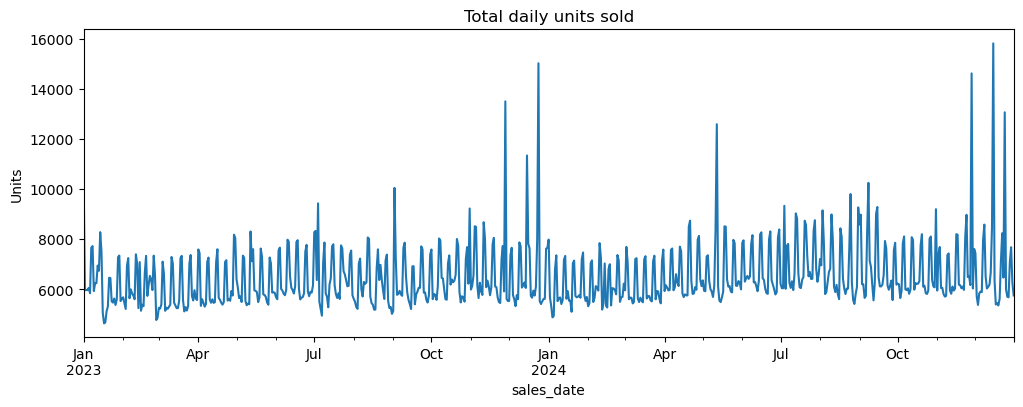

In [29]:
daily = sales_extended.groupby('sales_date')['units_sold'].sum()

daily.plot(figsize = (12, 4), title = 'Total daily units sold')
plt.ylabel('Units')
plt.show()

 # 7-day moving average to shows weekly pattern and trend

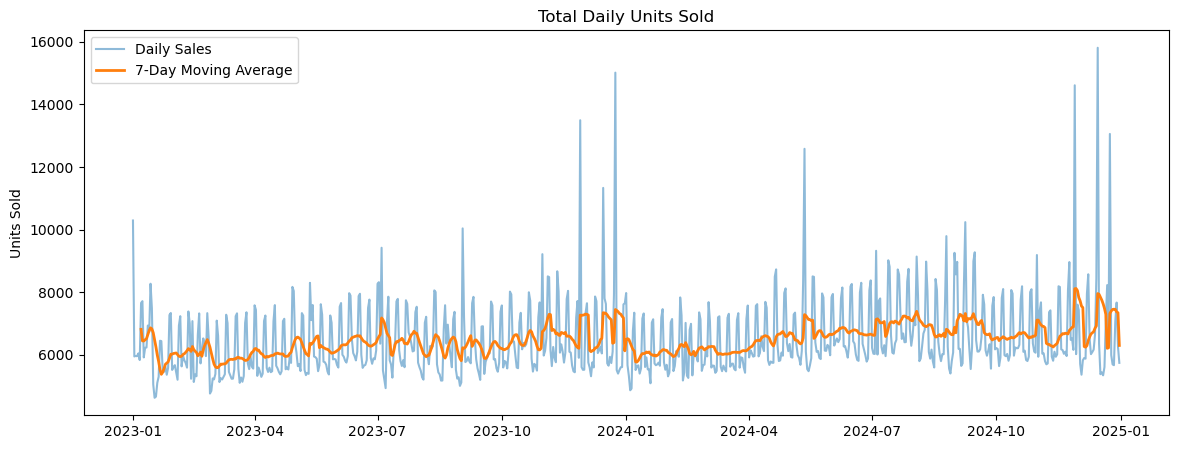

In [30]:
daily_ma7 = daily.rolling(7).mean()

plt.figure(figsize = (14,5))
plt.plot(daily.index, daily, alpha = 0.5, label = 'Daily Sales')
plt.plot(daily_ma7.index, daily_ma7, linewidth = 2, label = '7-Day Moving Average')

plt.title('Total Daily Units Sold')
plt.ylabel('Units Sold')
plt.legend()
plt.show()

### Exploring holiday spikes

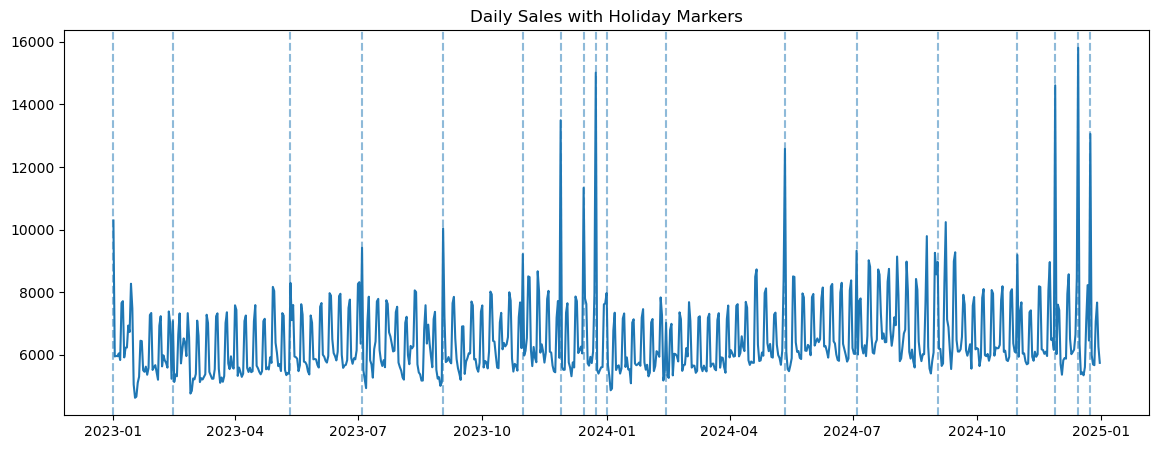

In [31]:
holiday_dates = sales_extended.loc[
    sales_extended['is_holiday'] == 1,
    'sales_date'
].unique()

plt.figure(figsize=(14,5))
plt.plot(daily.index, daily)

for holiday in holiday_dates:
    plt.axvline(
        holiday,
        linestyle = '--',
        alpha = 0.5
    )

plt.title('Daily Sales with Holiday Markers')
plt.show()

In [32]:
df_dim_calendar['holiday_name'].value_counts()

New Year's Day          2
Valentine's Day         2
Mother's Day Weekend    2
Independence Day        2
Labor Day Weekend       2
Halloween               2
Black Friday            2
Pre-Christmas Peak      2
Christmas Eve           2
Name: holiday_name, dtype: int64

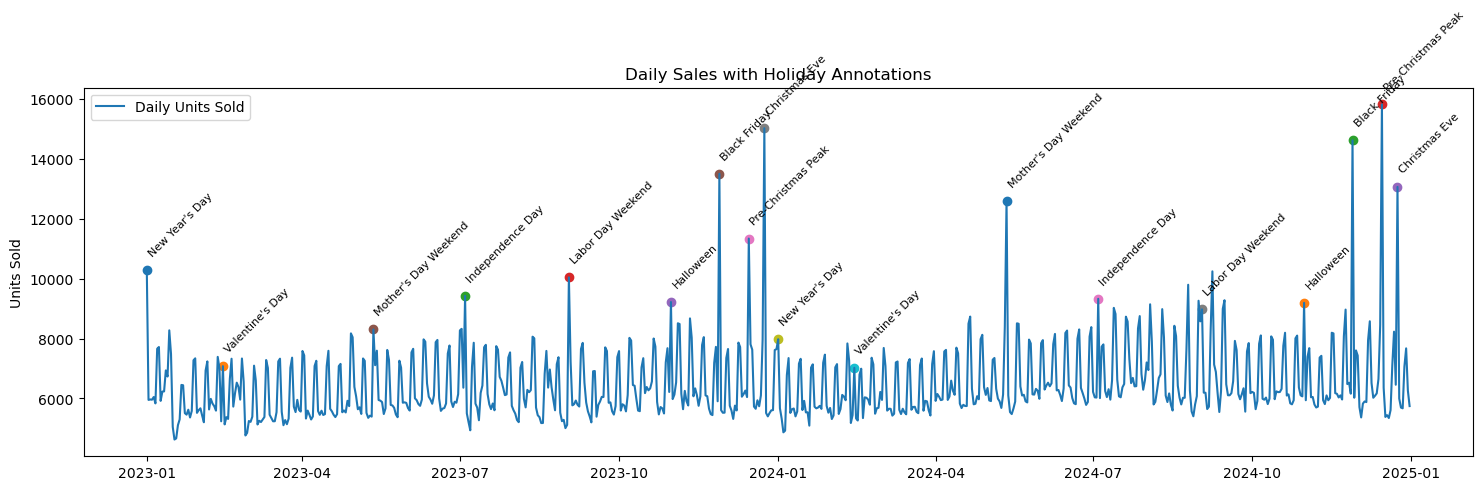

In [33]:
holiday_dates = (
    sales_extended[['sales_date', 'holiday_name']]
    .dropna()
    .drop_duplicates()
)

plt.figure(figsize=(15,5))

plt.plot(daily.index, daily.values, label='Daily Units Sold')

for _, row in holiday_dates.iterrows():
    date = row['sales_date']
    holiday = row['holiday_name']

    if date in daily.index:
        y = daily.loc[date]

        plt.scatter(date, y)

        plt.annotate(
            holiday,
            xy=(date, y),
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=8,
            rotation=45
        )

plt.title('Daily Sales with Holiday Annotations')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
holiday_sales = (
    sales_extended[sales_extended['holiday_name'].notna()]
    .groupby(['sales_date', 'holiday_name'])['units_sold', 'gross_revenue']
    .sum()
    .reset_index()
)

holiday_sales.sort_values('units_sold', ascending=False)

C:\Users\USER\AppData\Local\Temp\ipykernel_20716\572047513.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  sales_extended[sales_extended['holiday_name'].notna()]


,sales_date,holiday_name,units_sold,gross_revenue
16,2024-12-15,Pre-Christmas Peak,15807,271199.66
8,2023-12-24,Christmas Eve,15013,257033.79
15,2024-11-28,Black Friday,14609,232184.93
6,2023-11-28,Black Friday,13493,215868.92
17,2024-12-24,Christmas Eve,13056,223010.60
11,2024-05-12,Mother's Day Weekend,12581,183389.93
7,2023-12-15,Pre-Christmas Peak,11333,190673.77
0,2023-01-01,New Year's Day,10292,159306.82
4,2023-09-02,Labor Day Weekend,10040,156264.93
3,2023-07-04,Independence Day,9422,137010.58


### Exploring monthly seasonality

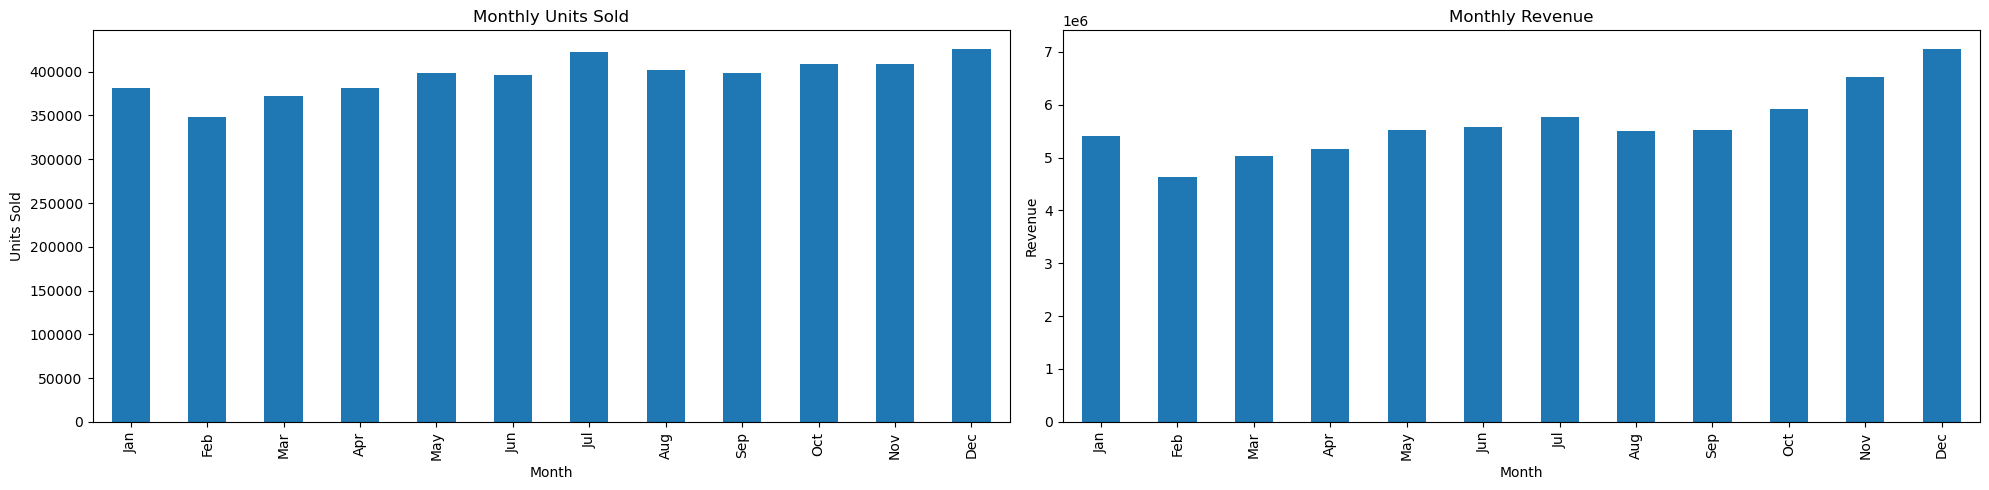

In [35]:
monthly = sales_extended.groupby(
    sales_extended['sales_date'].dt.strftime('%b')
)[['units_sold', 'gross_revenue']].sum()

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = monthly.reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Units Sold
monthly['units_sold'].plot(
    kind='bar',
    ax=axes[0],
    title='Monthly Units Sold'
)
axes[0].set_ylabel('Units Sold')
axes[0].set_xlabel('Month')

# Revenue
monthly['gross_revenue'].plot(
    kind='bar',
    ax=axes[1],
    title='Monthly Revenue'
)
axes[1].set_ylabel('Revenue')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()

### Exploring weekly seasonality

C:\Users\USER\AppData\Local\Temp\ipykernel_20716\2107095997.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  day_of_week = sales_extended.groupby(


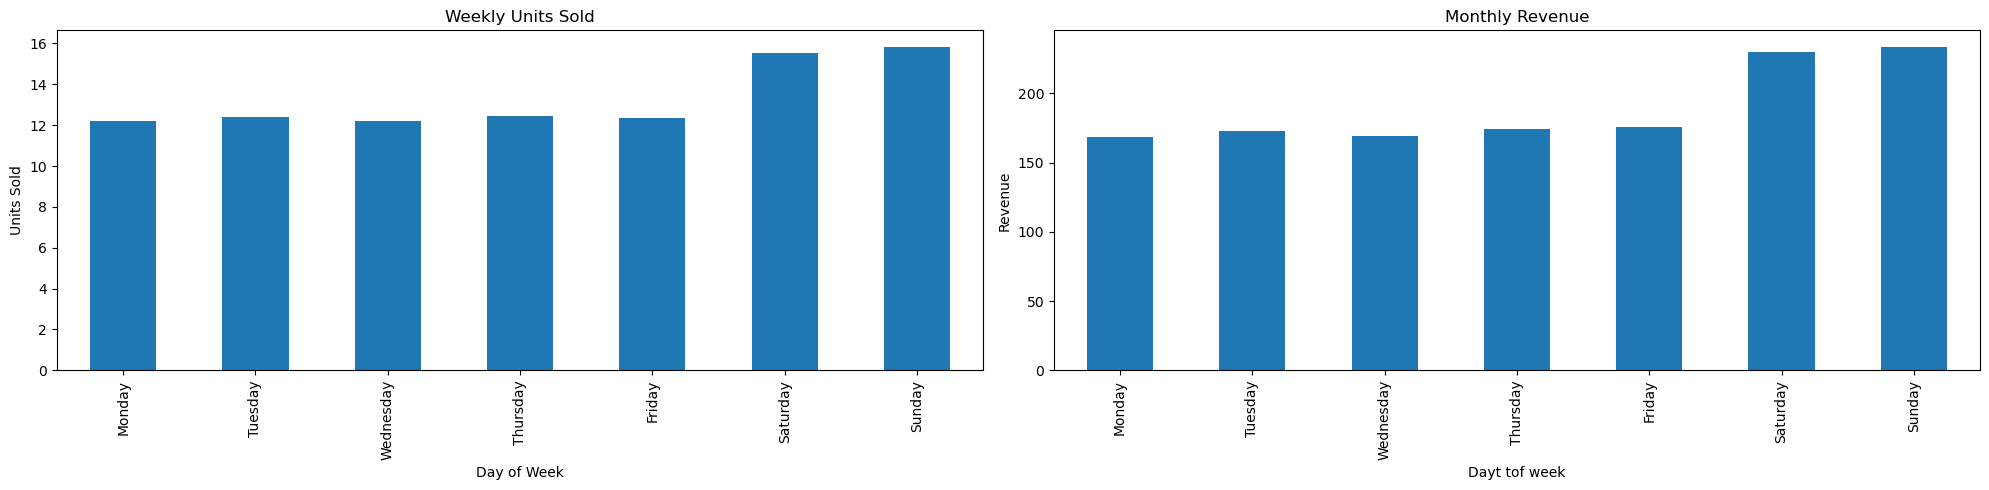

In [36]:
day_of_week = sales_extended.groupby(
    sales_extended['sales_date'].dt.day_name()
)['units_sold', 'gross_revenue'].mean()

day_of_week = day_of_week.reindex([
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
])

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Units Sold
day_of_week['units_sold'].plot(
    kind='bar',
    ax=axes[0],
    title='Weekly Units Sold'
)
axes[0].set_ylabel('Units Sold')
axes[0].set_xlabel('Day of Week')

# Revenue
day_of_week['gross_revenue'].plot(
    kind='bar',
    ax=axes[1],
    title='Monthly Revenue'
)
axes[1].set_ylabel('Revenue')
axes[1].set_xlabel('Dayt tof week')

plt.tight_layout()
plt.show()

### Demand distributions by category

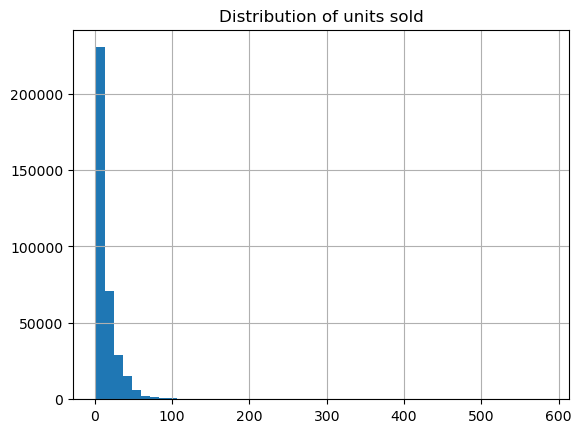

In [37]:
sales_extended['units_sold'].hist(bins=50)
plt.title('Distribution of units sold'); plt.show()


<Figure size 1200x600 with 0 Axes>

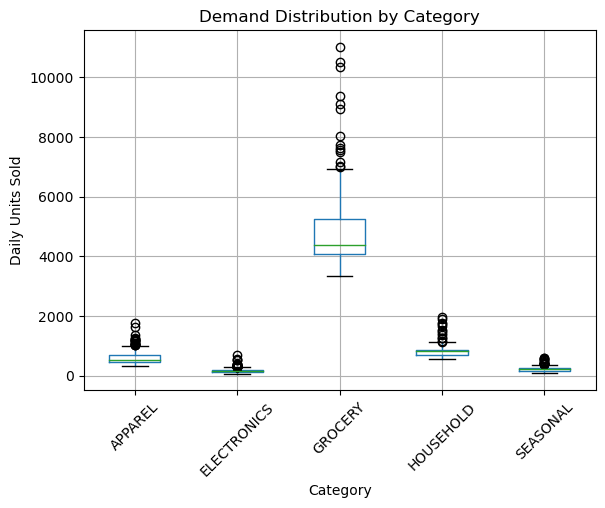

In [38]:
category_demand = (
    sales_extended
    .groupby(['category_id', 'sales_date'])['units_sold']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
category_demand.boxplot(
    column='units_sold',
    by='category_id',
    rot=45
)

plt.title('Demand Distribution by Category')
plt.suptitle('')
plt.xlabel('Category')
plt.ylabel('Daily Units Sold')
plt.show()

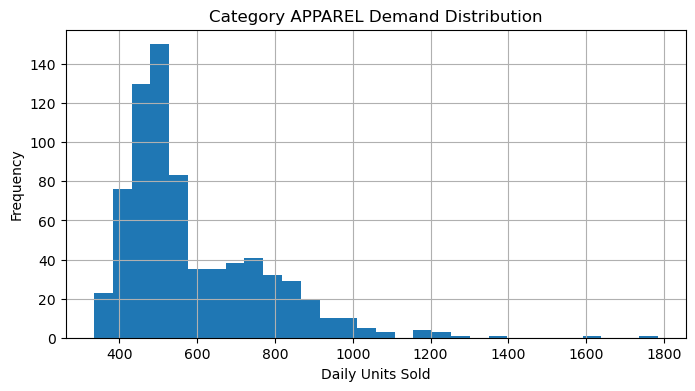

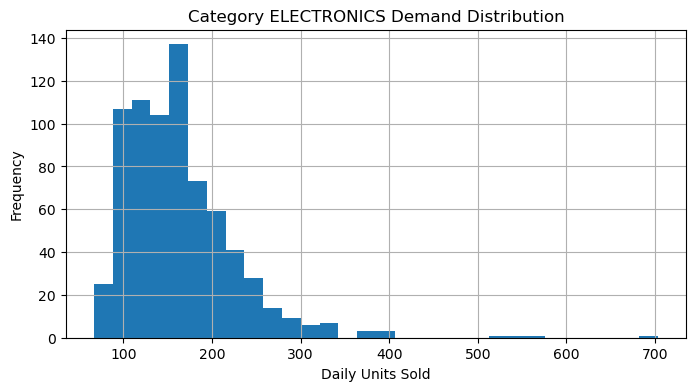

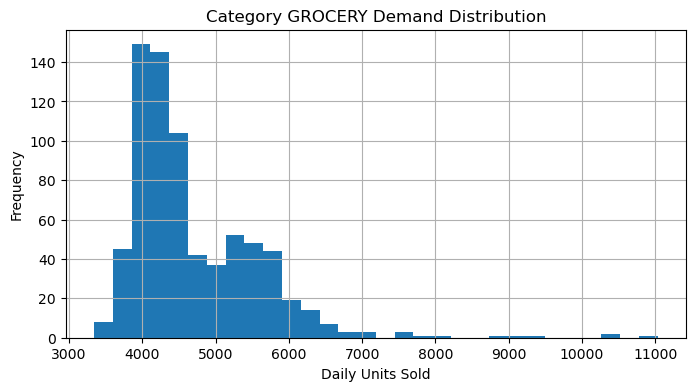

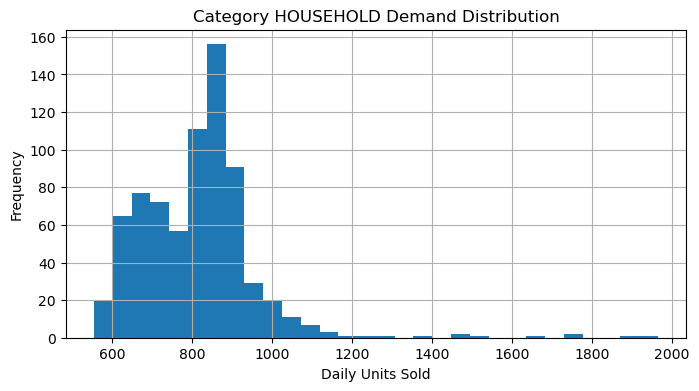

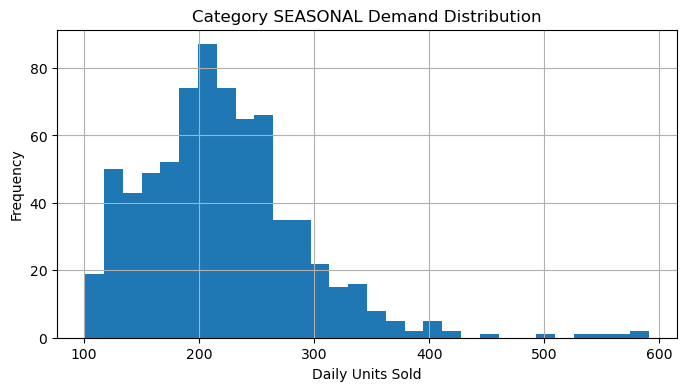

In [39]:
categories = category_demand['category_id'].unique()

for cat in categories:
    plt.figure(figsize=(8, 4))

    category_demand.loc[
        category_demand['category_id'] == cat,
        'units_sold'
    ].hist(bins=30)

    plt.title(f'Category {cat} Demand Distribution')
    plt.xlabel('Daily Units Sold')
    plt.ylabel('Frequency')
    plt.show()

### Quantifying skewness

In [40]:
skewness = (
    category_demand
    .groupby('category_id')['units_sold']
    .skew()
    .sort_values(ascending=False)
)

print(skewness)

category_id
HOUSEHOLD      2.411021
ELECTRONICS    2.317297
GROCERY        2.228845
APPAREL        1.677047
SEASONAL       1.244395
Name: units_sold, dtype: float64


### Measuring intermittency for slow movers

In [41]:
daily_category = (
    sales_extended
    .groupby(['category_id', 'sales_date'])['units_sold']
    .sum()
    .reset_index()
)

intermittency = (
    daily_category
    .assign(zero_sales = lambda x: x['units_sold'] == 0)
    .groupby('category_id')['zero_sales']
    .mean()
    .mul(100)
    .round(1)
)

print(intermittency.sort_values(ascending=False))

category_id
APPAREL        0.0
ELECTRONICS    0.0
GROCERY        0.0
HOUSEHOLD      0.0
SEASONAL       0.0
Name: zero_sales, dtype: float64


In [42]:
summary = (
    daily_category
    .groupby('category_id')
    .agg(
        avg_daily_demand=('units_sold', 'mean'),
        median_daily_demand=('units_sold', 'median'),
        max_daily_demand=('units_sold', 'max'),
        skewness=('units_sold', 'skew')
    )
)

summary['pct_zero_sales_days'] = (
    daily_category
    .assign(zero_sales=lambda x: x['units_sold'] == 0)
    .groupby('category_id')['zero_sales']
    .mean()
    * 100
)

summary = summary.round(2)

summary.sort_values('skewness', ascending=False)

,avg_daily_demand,median_daily_demand,max_daily_demand,skewness,pct_zero_sales_days
category_id,,,,,
HOUSEHOLD,813.69,821.0,1965,2.41,0.0
ELECTRONICS,163.42,154.0,703,2.32,0.0
GROCERY,4704.09,4398.0,11035,2.23,0.0
APPAREL,589.07,522.0,1784,1.68,0.0
SEASONAL,220.16,214.0,591,1.24,0.0


### Summary of demand patterns


Daily Sales Trend

Sales trend shows a daily moving average of units sold between 5k to 7k per day year in year out with spikes explained by holidays and seasonality (pre-chrismas peaks, mothers day weekend, Labor day weekend).
Monthly trends shows largest volumes of units sold  in December and July, corresponding months with largest gross revenus are December and November.
Weekly trends record the weekend (Saturday and Sunday) with highest number of average units sold and average revenue generated.

Distribution of daily units sold is evidently right skewed.

By category, distributions are generally skewed to the right with household items having the greatest degree of skew.